In [ ]:
from pathlib import Path
import pandas as pd

RESULTS_DIR   = Path(".")
OMNI_KEY_FILE = Path("data/omni_reader_list.xlsx")
OUTPUT_FILE   = Path("organized_survey_results.xlsx")

READER_MAP = {
    "behnia": 1,
    "msadic": 2,
    "noha": 3,
    "mkumar1": 4,
    "oztekma": 2,
    "laithab": 5
}

QUESTIONS = ["image_quality","noise","confidence","acceptability"]

def main():
    omni = pd.read_excel(OMNI_KEY_FILE)
    omni.columns = omni.columns.astype(str).str.strip()

    all_results = []

    for reader, reader_id in READER_MAP.items():
        df = pd.read_excel(RESULTS_DIR / f"CT_Lesions_Results_{reader}.xlsx")
        df.columns = df.columns.astype(str).str.strip()
        df["patient_id"] = df["patient_id"].astype(str).str.strip()

        key_col = f"reader {reader_id}"

        lookup = omni[["Key", "Patient ID", "Series Desc", key_col]].copy()

        lookup[key_col] = lookup[key_col].astype(str).str.strip()

        df = df.merge(lookup,
            left_on="patient_id",
            right_on=key_col,
            how="left")

        df["reader"] = reader
        all_results.append(df[["Key", "Patient ID", "Series Desc", "reader"] + QUESTIONS])

    long = pd.concat(all_results, ignore_index=True)
    long[QUESTIONS] = long[QUESTIONS].apply(
        pd.to_numeric, errors="coerce")

    # Convert questions to rows
    long = long.melt(
        id_vars=["Key", "Patient ID", "Series Desc", "reader"],
        value_vars=QUESTIONS,
        var_name="Question",
        value_name="Response")

    # Reader names become columns
    final = long.pivot_table(
        index=["Key", "Patient ID", "Series Desc", "Question"],
        columns="reader",
        values="Response",
        aggfunc="first").reset_index()

    final.columns.name = None
    # Rename reader columns
    final = final.rename(columns={reader: reader for reader in READER_MAP})
    reader_order = list(READER_MAP.keys())
    final = final[["Key", "Patient ID", "Series Desc", "Question"] + reader_order]
    final = final.sort_values(["Key", "Question"]).reset_index(drop=True)

    print(f"Rows: {len(final)}")
    print(f"Cases: {final['Key'].nunique()}")

    print("\nRows per case:")
    print(final.groupby("Key")
        .size()
        .value_counts()
        .sort_index())

    final.to_excel(OUTPUT_FILE,index=False)
    print(f"\nSaved: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()




FileNotFoundError: [Errno 2] No such file or directory: 'omni_reader_PET_key.xlsx'


Number of patients per reader/reconstruction/time:
Reader   MPDL      Time
behnia   MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0     10
                   2.5     10
laithab  MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0      9
                   2.5     10
mkumar1  MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0      9
                   2.5     10
msadic   MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5      9
                   2.0     10
                   2.5     10
noha     MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0     10
                   2.5      9
oztekma  MPDL      1.5  

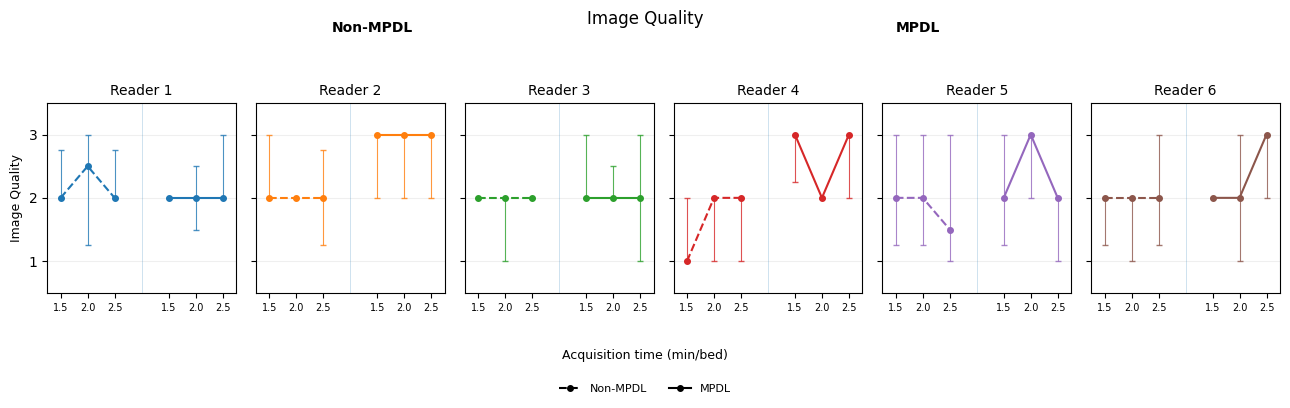

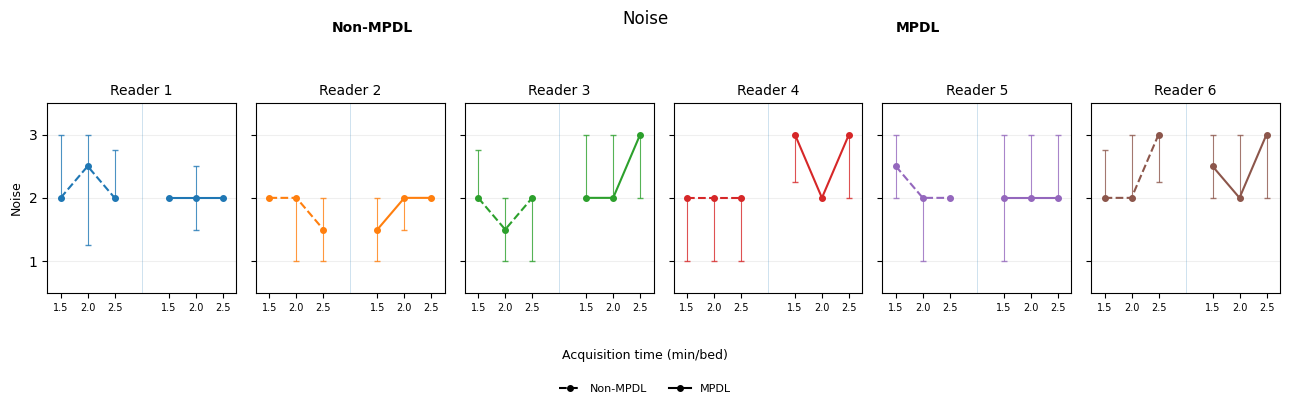

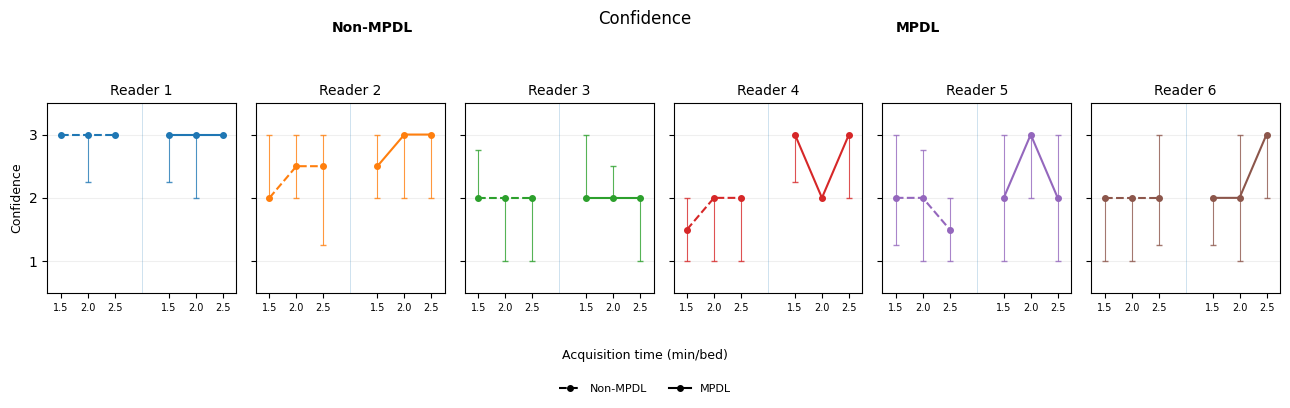

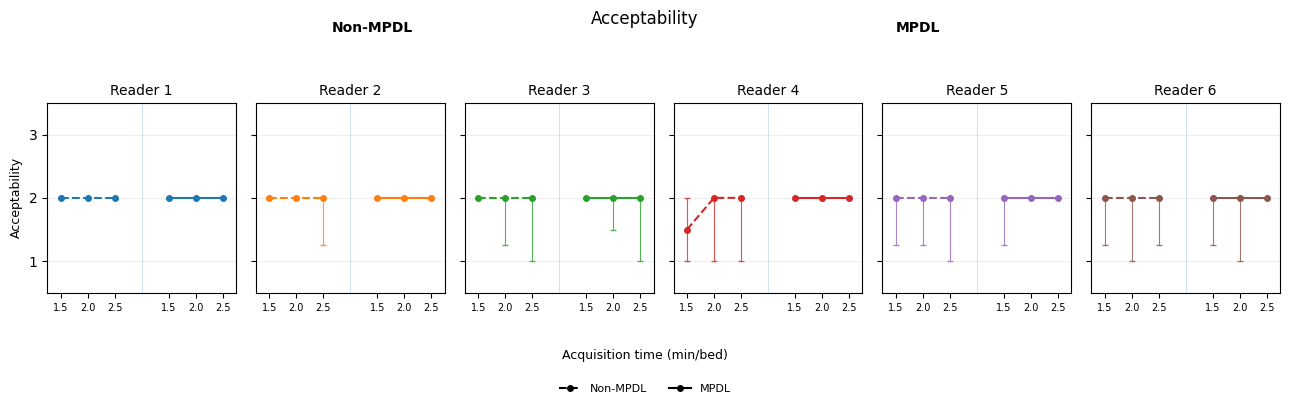

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE = Path("organized_survey_results.xlsx")
OUT = Path("figures")
OUT.mkdir(exist_ok=True)

QUESTIONS = ["image_quality","noise","confidence","acceptability"]
LABELS = {
    "image_quality": "Image Quality",
    "noise": "Noise",
    "confidence": "Confidence",
    "acceptability": "Acceptability"
}

READERS = ["behnia","msadic","noha","mkumar1","oztekma","laithab"]

READER_ID = {
    "behnia": 1,
    "msadic": 2,
    "noha": 3,
    "mkumar1": 4,
    "oztekma": 5,
    "laithab": 6
}

df = pd.read_excel(FILE)
df.columns = df.columns.astype(str).str.strip()

df["Series Desc"] = (
    df["Series Desc"]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

long = df.melt(
    id_vars=["Key", "Patient ID", "Series Desc", "Question"],
    value_vars=READERS,
    var_name="Reader",
    value_name="Rating"
)

long["Rating"] = pd.to_numeric(long["Rating"], errors="coerce")

long["Time"] = pd.to_numeric(
    long["Series Desc"].str.extract(
        r"(1\.5|2\.0|2\.5)\s*min\s*/\s*be[dtg]",
        expand=False
    ),
    errors="coerce"
)

long["MPDL"] = np.where(
    long["Series Desc"].str.contains(
        "MPDL",
        case=False,
        na=False
    ),
    "MPDL",
    "Non-MPDL"
)

long = long.dropna(
    subset=["Rating", "Time"]
)

# Median and IQR across the 10 patients
summary = (
    long.groupby(
        ["Question", "Reader", "MPDL", "Time"]
    )["Rating"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n="count"
    )
    .reset_index()
)

# QC
print("\nNumber of patients per reader/reconstruction/time:")
print(
    long.groupby(
        ["Reader", "MPDL", "Time"]
    )["Patient ID"]
    .nunique()
)

# x positions
xpos = {
    (1.5, "Non-MPDL"): 1,
    (2.0, "Non-MPDL"): 2,
    (2.5, "Non-MPDL"): 3,
    (1.5, "MPDL"): 5,
    (2.0, "MPDL"): 6,
    (2.5, "MPDL"): 7
}

for question in QUESTIONS:
    d = summary[summary["Question"] == question]
    fig, axes = plt.subplots(1,6,figsize=(13, 3.2),
        sharey=True)

    for i, reader in enumerate(READERS):
        ax = axes[i]
        p = d[d["Reader"] == reader]

        color = plt.cm.tab10(i)
        for mpdl, linestyle in [("Non-MPDL", "--"),("MPDL", "-")]:
            q = p[p["MPDL"] == mpdl].copy()
            if q.empty:
                continue

            q["x"] = [xpos[(t, mpdl)] for t in q["Time"]]
            q      = q.sort_values("x")

            # Median
            ax.plot(
                q["x"],
                q["median"],
                color=color,
                linestyle=linestyle,
                linewidth=1.5,
                marker="o",
                markersize=4)

            # IQR
            ax.errorbar(
                q["x"],
                q["median"],
                yerr=[
                    q["median"] - q["q25"],
                    q["q75"] - q["median"]
                ],
                fmt="none",
                ecolor=color,
                elinewidth=0.8,
                capsize=2,
                alpha=0.8
            )

        ax.set_title(f"Reader {READER_ID[reader]}",fontsize=10)
        ax.set_xticks([1, 2, 3, 5, 6, 7])
        ax.set_xticklabels(["1.5", "2.0", "2.5","1.5", "2.0", "2.5"],fontsize=7)
        ax.set_xlim(0.5,7.5)
        ax.set_ylim(0.5,3.5)
        ax.set_yticks([1, 2, 3])
        ax.axvline(4,linewidth=0.6,alpha=0.25)
        ax.grid(axis="y",alpha=0.2)

        if i > 0:
            ax.tick_params(
                labelleft=False
            )

    axes[0].set_ylabel(LABELS[question],fontsize=9)

    # Reconstruction labels
    fig.text(0.29,1.01,"Non-MPDL",ha="center",fontsize=10,fontweight="bold")
    fig.text(0.71,1.01,"MPDL",ha="center",fontsize=10,fontweight="bold")
    fig.suptitle(LABELS[question],y=1.08,fontsize=12)
    fig.supxlabel("Acquisition time (min/bed)",y=-0.02,fontsize=9)

    # Line-style legend
    from matplotlib.lines import Line2D

    legend = [
        Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            marker="o",
            linewidth=1.5,
            markersize=4,
            label="Non-MPDL"
        ),
        Line2D([0], [0],
            color="black",
            linestyle="-",
            marker="o",
            linewidth=1.5,
            markersize=4,
            label="MPDL")]

    fig.legend(handles=legend,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        frameon=False,
        fontsize=8)

    plt.tight_layout()

    fig.savefig(
        OUT / f"{question}_six_readers.png",
        dpi=300,
        bbox_inches="tight")

    fig.savefig(
        OUT / f"{question}_six_readers.pdf",
        bbox_inches="tight")

    plt.show()
    plt.close(fig)




Number of patients per reader/reconstruction/time:
Reader   MPDL      Time
behnia   MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0     10
                   2.5     10
laithab  MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0      9
                   2.5     10
mkumar1  MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0      9
                   2.5     10
msadic   MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5      9
                   2.0     10
                   2.5     10
noha     MPDL      1.5     10
                   2.0     10
                   2.5      9
         Non-MPDL  1.5     10
                   2.0     10
                   2.5      9
oztekma  MPDL      1.5  

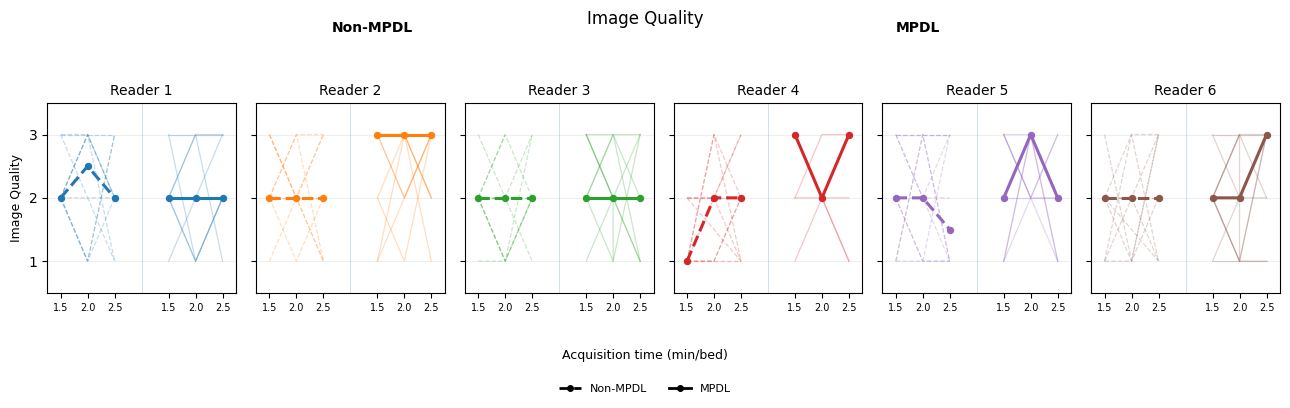

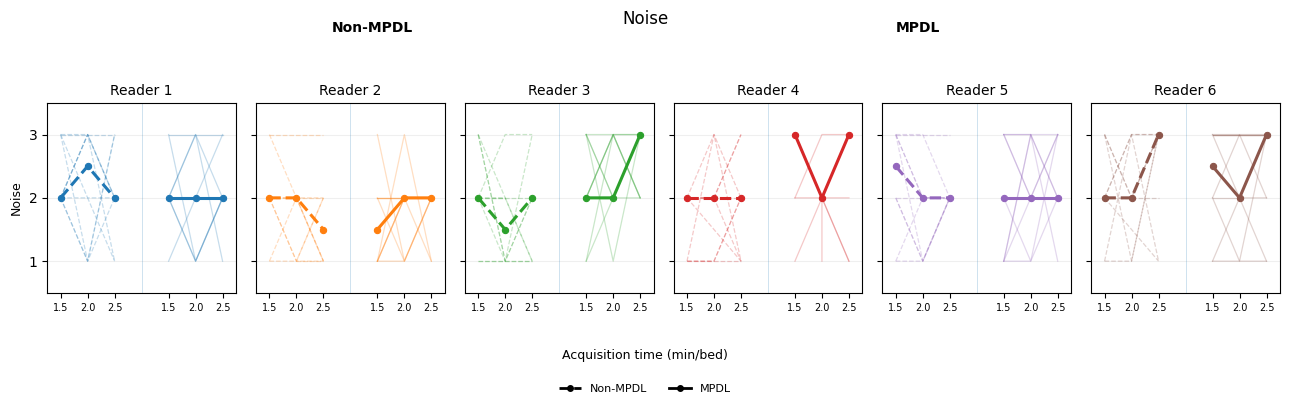

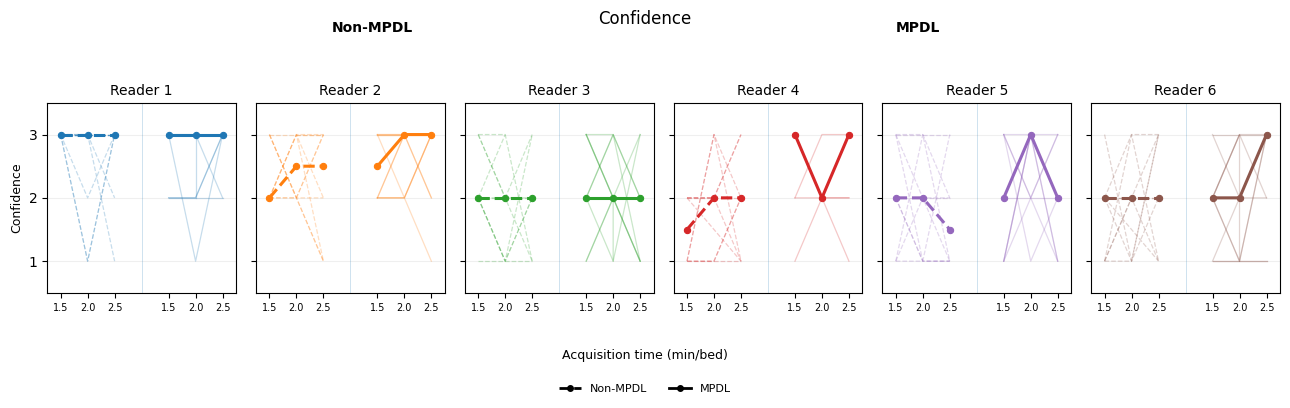

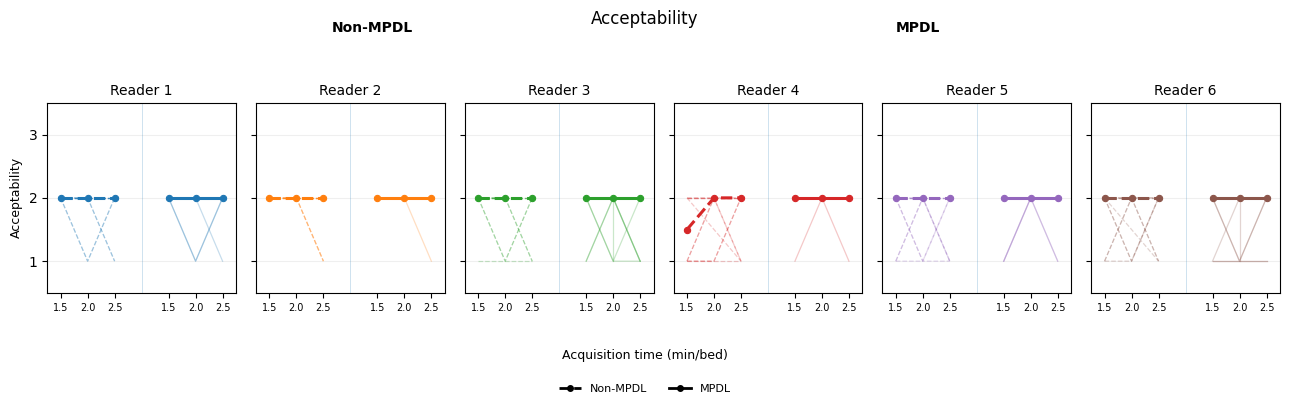

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# SETTINGS
FILE = Path("organized_survey_results.xlsx")
OUT  = Path("figures")
OUT.mkdir(exist_ok=True)

QUESTIONS = ["image_quality","noise","confidence","acceptability"]

LABELS = {
    "image_quality": "Image Quality",
    "noise": "Noise",
    "confidence": "Confidence",
    "acceptability": "Acceptability"
}

READERS   = ["behnia","msadic","noha","mkumar1","oztekma","laithab"]
READER_ID = {
    "behnia": 1,
    "msadic": 2,
    "noha": 3,
    "mkumar1": 4,
    "oztekma": 5,
    "laithab": 6}


# LOAD DATA
df         = pd.read_excel(FILE)
df.columns = df.columns.astype(str).str.strip()
# Clean Series Description
df["Series Desc"] = (df["Series Desc"]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())


# CONVERT TO LONG FORMAT
long = df.melt(
    id_vars=["Key","Patient ID","Series Desc","Question"],
    value_vars=READERS,var_name="Reader",value_name="Rating")

long["Rating"] = pd.to_numeric(long["Rating"],errors="coerce")

# EXTRACT ACQUISITION TIME
long["Time"] = pd.to_numeric(long["Series Desc"].str.extract(r"(1\.5|2\.0|2\.5)\s*min\s*/\s*be[dtg]",expand=False),errors="coerce")

# IDENTIFY MPDL
long["MPDL"] = np.where(long["Series Desc"].str.contains("MPDL",case=False,na=False),"MPDL","Non-MPDL")

# REMOVE INCOMPLETE OBSERVATIONS
long = long.dropna(subset=["Rating","Time","Patient ID"])

# QC
print("\nNumber of patients per reader/reconstruction/time:")
print(long.groupby(["Reader", "MPDL", "Time"])["Patient ID"].nunique())
print("\nNumber of observations:")
print(len(long))


# X POSITIONS
xpos = {
    (1.5, "Non-MPDL"): 1,
    (2.0, "Non-MPDL"): 2,
    (2.5, "Non-MPDL"): 3,
    (1.5, "MPDL"): 5,
    (2.0, "MPDL"): 6,
    (2.5, "MPDL"): 7
}


# READER COLORS
colors = plt.cm.tab10(np.arange(len(READERS)))


# PLOT
for question in QUESTIONS:
    d = long[long["Question"] == question].copy()
    
    # Calculate median for each reader / reconstruction / time
    median_data = (
        d.groupby(
            ["Reader", "MPDL", "Time"]
        )["Rating"]
        .median()
        .reset_index())

    fig, axes = plt.subplots(1,6,figsize=(13, 3.2),sharey=True)

    for i, reader in enumerate(READERS):
        ax = axes[i]
        p = d[d["Reader"] == reader].copy()
        color = colors[i]

        # INDIVIDUAL PATIENT LINES
        patients = sorted(p["Patient ID"].unique())

        for patient in patients:
            patient_data = p[
                p["Patient ID"] == patient].copy()

            for mpdl, linestyle in [
                ("Non-MPDL", "--"),
                ("MPDL", "-")]:
                q = patient_data[patient_data["MPDL"] == mpdl].copy()

                if q.empty:
                    continue

                q["x"] = [xpos[(t, mpdl)]for t in q["Time"]]

                q = q.sort_values("x")
                # Individual patient
                # Same color for all patients within reader
                # Transparent, line only
                ax.plot(
                    q["x"],
                    q["Rating"],
                    color=color,
                    linestyle=linestyle,
                    linewidth=0.9,
                    alpha=0.25)

        # MEDIAN LINE
        med = median_data[median_data["Reader"] == reader].copy()

        for mpdl, linestyle in [
            ("Non-MPDL", "--"),
            ("MPDL", "-")]:

            q = med[med["MPDL"] == mpdl].copy()

            if q.empty:
                continue

            q["x"] = [xpos[(t, mpdl)] for t in q["Time"]]

            q = q.sort_values("x")

            # Median:
            # opaque
            # marker
            # thicker line
            ax.plot(
                q["x"],
                q["Rating"],
                color=color,
                linestyle=linestyle,
                linewidth=2.2,
                marker="o",
                markersize=4.5,
                markeredgewidth=0.8,
                alpha=1.0,
                zorder=10
            )
        
        # READER TITLE
        ax.set_title(f"Reader {READER_ID[reader]}",fontsize=10)

        # X AXIS
        ax.set_xticks([1, 2, 3, 5, 6, 7])
        ax.set_xticklabels(["1.5","2.0","2.5","1.5","2.0","2.5"],fontsize=7)
        ax.set_xlim(0.5,7.5)
        
        # Y AXIS
        ax.set_ylim(0.5,3.5)
        ax.set_yticks([1, 2, 3])

        # VISUAL SEPARATOR
        ax.axvline(4,linewidth=0.6,alpha=0.25)
        ax.grid(axis="y",alpha=0.2)

        if i > 0:
            ax.tick_params(
                labelleft=False)


    # LABELS
    axes[0].set_ylabel(
        LABELS[question],
        fontsize=9
    )

    fig.text(
        0.29,
        1.01,
        "Non-MPDL",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

    fig.text(
        0.71,
        1.01,
        "MPDL",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

    fig.suptitle(
        LABELS[question],
        y=1.08,
        fontsize=12
    )

    fig.supxlabel(
        "Acquisition time (min/bed)",
        y=-0.02,
        fontsize=9
    )


    # LEGEND
    from matplotlib.lines import Line2D

    legend = [
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            marker="o",
            linewidth=2.0,
            markersize=4,
            label="Non-MPDL"
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="-",
            marker="o",
            linewidth=2.0,
            markersize=4,
            label="MPDL"
        )
    ]

    fig.legend(
        handles=legend,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        frameon=False,
        fontsize=8
    )


    # SAVE
    plt.tight_layout()

    fig.savefig(
        OUT / f"{question}_six_readers_all_patients_median.png",
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        OUT / f"{question}_six_readers_all_patients_median.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)




Number of readers per patient/reconstruction/time:
MPDL       MPDL      Non-MPDL           MPDL
Time        1.5  2.0      1.5  2.0  2.5  2.5
Patient ID                                  
ANON10180   6.0  6.0      6.0  6.0  6.0  NaN
ANON19571   6.0  6.0      6.0  6.0  5.0  6.0
ANON21650   6.0  6.0      6.0  6.0  6.0  6.0
ANON27988   6.0  6.0      6.0  6.0  6.0  6.0
ANON31610   6.0  6.0      6.0  6.0  6.0  6.0
ANON43994   6.0  6.0      5.0  6.0  6.0  6.0
ANON45237   6.0  6.0      6.0  6.0  6.0  6.0
ANON56069   6.0  6.0      6.0  6.0  6.0  6.0
ANON88156   6.0  6.0      6.0  5.0  6.0  6.0
ANON89534   6.0  6.0      6.0  5.0  6.0  6.0

Total observations: 1424


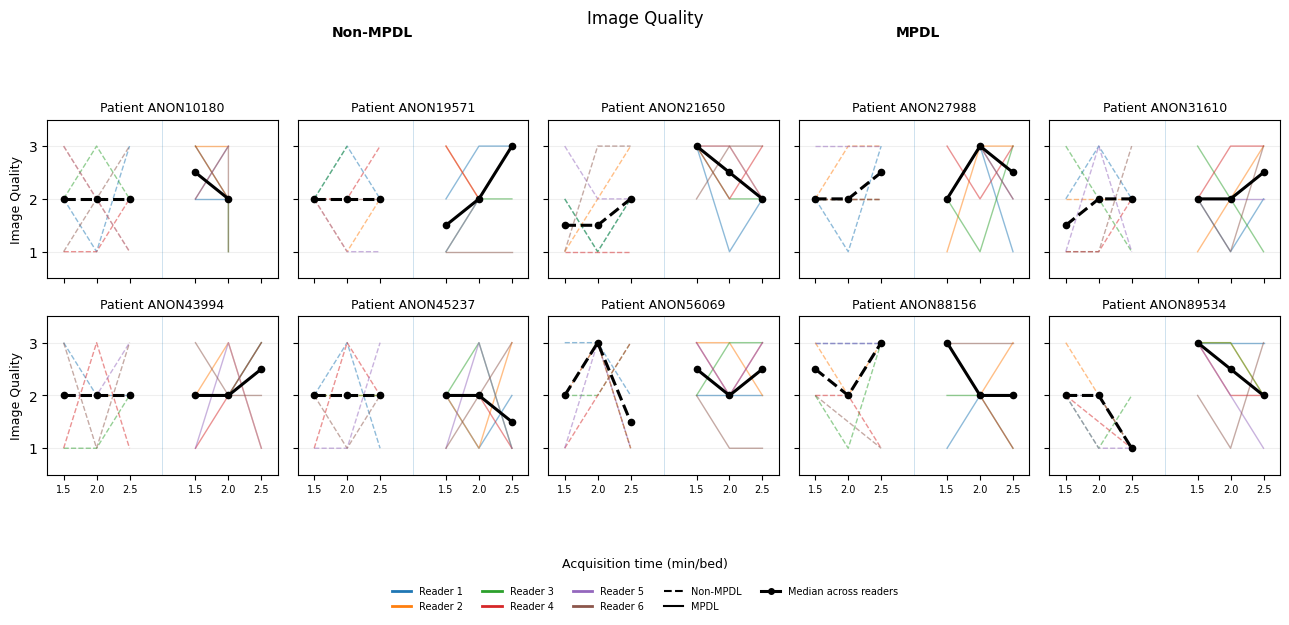

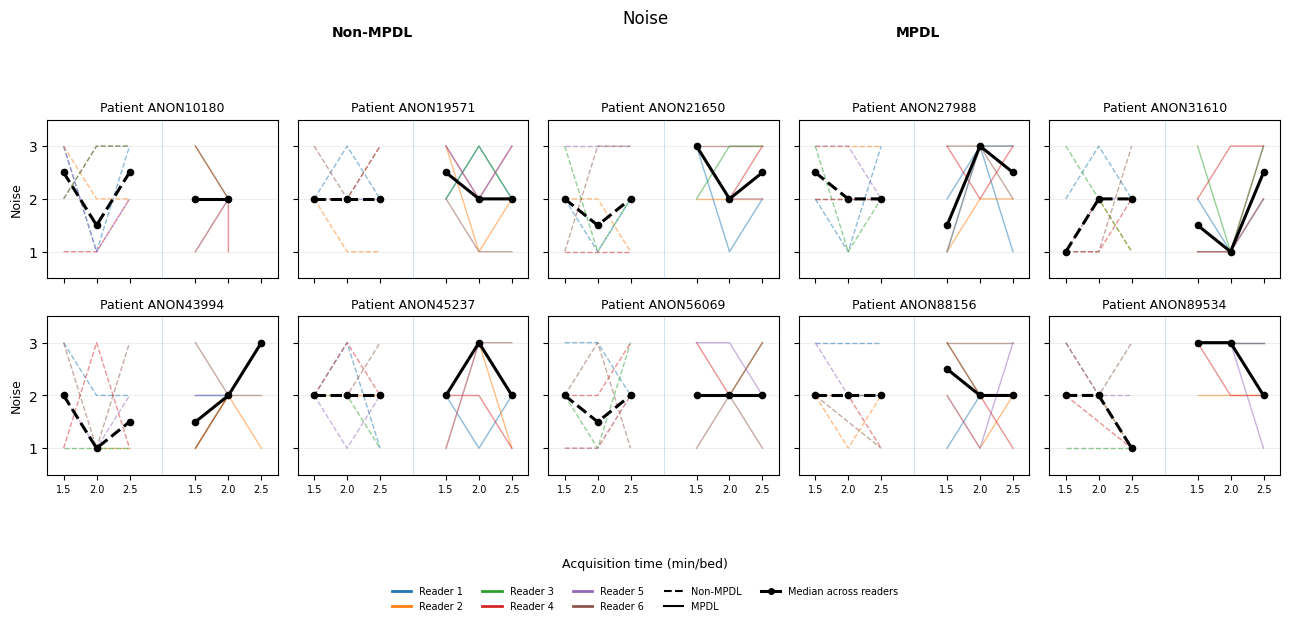

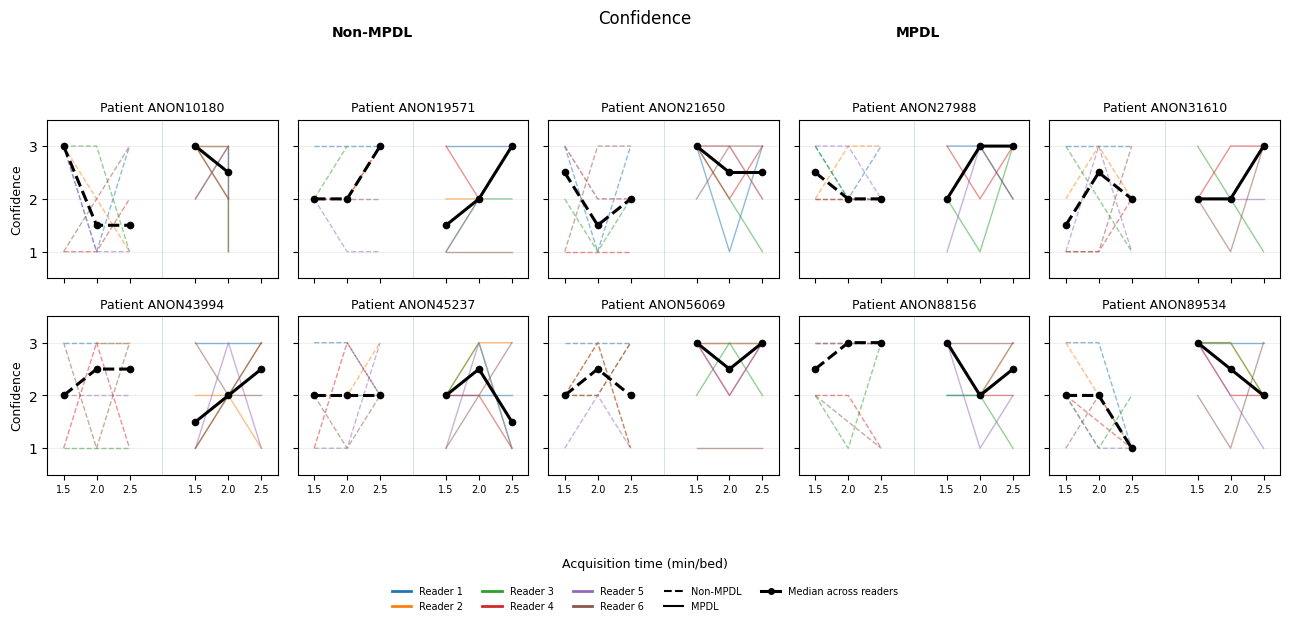

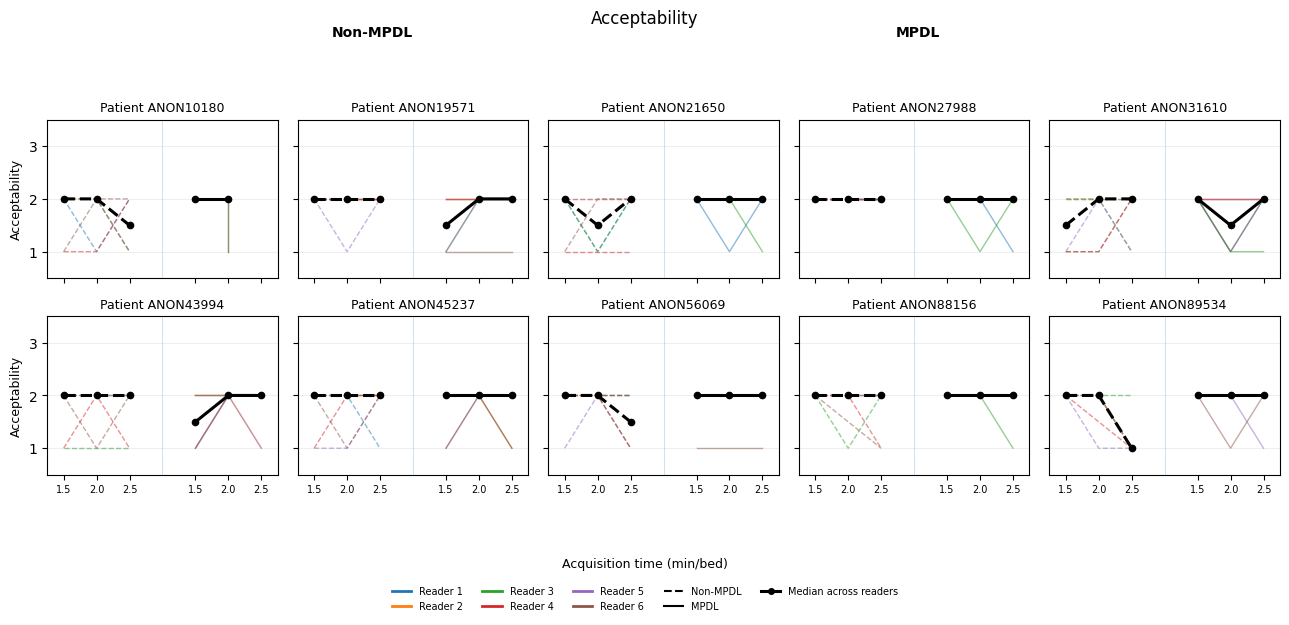

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FILE = Path("organized_survey_results.xlsx")
OUT = Path("figures")
OUT.mkdir(exist_ok=True)

QUESTIONS = ["image_quality", "noise", "confidence", "acceptability"]

LABELS = {
    "image_quality": "Image Quality",
    "noise": "Noise",
    "confidence": "Confidence",
    "acceptability": "Acceptability"
}

READERS = ["behnia", "msadic", "noha", "mkumar1", "oztekma", "laithab"]

READER_ID = {
    "behnia": 1, "msadic": 2, "noha": 3,
    "mkumar1": 4, "oztekma": 5, "laithab": 6
}

df = pd.read_excel(FILE)
df.columns = df.columns.astype(str).str.strip()

df["Series Desc"] = (
    df["Series Desc"].astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

long = df.melt(
    id_vars=["Key", "Patient ID", "Series Desc", "Question"],
    value_vars=READERS,
    var_name="Reader",
    value_name="Rating"
)

long["Rating"] = pd.to_numeric(long["Rating"], errors="coerce")

long["Time"] = pd.to_numeric(
    long["Series Desc"].str.extract(
        r"(1\.5|2\.0|2\.5)\s*min\s*/\s*be[dtg]",
        expand=False
    ),
    errors="coerce"
)

long["MPDL"] = np.where(
    long["Series Desc"].str.contains("MPDL", case=False, na=False),
    "MPDL",
    "Non-MPDL"
)

long = long.dropna(subset=["Rating", "Time", "Patient ID"])

# QC: number of readers for each patient / reconstruction / time
print("\nNumber of readers per patient/reconstruction/time:")
print(
    long.groupby(
        ["Patient ID", "MPDL", "Time"]
    )["Reader"]
    .nunique()
    .unstack(["MPDL", "Time"])
    .to_string()
)

print("\nTotal observations:", len(long))

xpos = {
    (1.5, "Non-MPDL"): 1, (2.0, "Non-MPDL"): 2,
    (2.5, "Non-MPDL"): 3, (1.5, "MPDL"): 5,
    (2.0, "MPDL"): 6, (2.5, "MPDL"): 7
}

colors = plt.cm.tab10(np.arange(len(READERS)))
reader_colors = dict(zip(READERS, colors))

for question in QUESTIONS:

    d = long[long["Question"] == question].copy()

    median_data = (
        d.groupby(["Patient ID", "MPDL", "Time"])["Rating"]
        .median()
        .reset_index()
    )

    patients = sorted(d["Patient ID"].unique())

    fig, axes = plt.subplots(
        2, 5,
        figsize=(13, 5.5),
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()

    for i, patient in enumerate(patients):

        ax = axes[i]
        p = d[d["Patient ID"] == patient]

        for reader in READERS:
            r = p[p["Reader"] == reader]

            for mpdl, linestyle in [("Non-MPDL", "--"), ("MPDL", "-")]:
                q = r[r["MPDL"] == mpdl].copy()

                if q.empty:
                    continue

                q["x"] = [xpos[(t, mpdl)] for t in q["Time"]]
                q = q.sort_values("x")

                ax.plot(
                    q["x"], q["Rating"],
                    color=reader_colors[reader],
                    linestyle=linestyle,
                    linewidth=1,
                    alpha=0.50
                )

        med = median_data[median_data["Patient ID"] == patient]

        for mpdl, linestyle in [("Non-MPDL", "--"), ("MPDL", "-")]:
            q = med[med["MPDL"] == mpdl].copy()

            if q.empty:
                continue

            q["x"] = [xpos[(t, mpdl)] for t in q["Time"]]
            q = q.sort_values("x")

            ax.plot(
                q["x"], q["Rating"],
                color="black",
                linestyle=linestyle,
                linewidth=2.2,
                marker="o",
                markersize=4.5,
                zorder=10
            )

        ax.set_title(f"Patient {patient}", fontsize=9)
        ax.set_xlim(0.5, 7.5)
        ax.set_ylim(0.5, 3.5)
        ax.set_xticks([1, 2, 3, 5, 6, 7])
        ax.set_xticklabels(
            ["1.5", "2.0", "2.5", "1.5", "2.0", "2.5"],
            fontsize=7
        )
        ax.set_yticks([1, 2, 3])
        ax.grid(axis="y", alpha=0.2)
        ax.axvline(4, linewidth=0.6, alpha=0.25)

    axes[0].set_ylabel(LABELS[question], fontsize=9)
    axes[5].set_ylabel(LABELS[question], fontsize=9)

    fig.supxlabel("Acquisition time (min/bed)", y=0.02, fontsize=9)
    fig.suptitle(LABELS[question], y=1.04, fontsize=12)

    fig.text(
        0.29, 0.99, "Non-MPDL",
        ha="center", fontsize=10, fontweight="bold"
    )
    fig.text(
        0.71, 0.99, "MPDL",
        ha="center", fontsize=10, fontweight="bold"
    )

    reader_legend = [
        Line2D(
            [0], [0],
            color=reader_colors[r],
            linewidth=2,
            label=f"Reader {READER_ID[r]}"
        )
        for r in READERS
    ]

    style_legend = [
        Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="Non-MPDL"
        ),
        Line2D(
            [0], [0],
            color="black",
            linestyle="-",
            linewidth=1.5,
            label="MPDL"
        ),
        Line2D(
            [0], [0],
            color="black",
            linestyle="-",
            linewidth=2.2,
            marker="o",
            markersize=4,
            label="Median across readers"
        )
    ]

    fig.legend(
        handles=reader_legend + style_legend,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=5,
        frameon=False,
        fontsize=7
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.96])

    fig.savefig(
        OUT / f"{question}_ten_patients_readers_median.png",
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        OUT / f"{question}_ten_patients_readers_median.pdf",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    

In [ ]:
import pandas as pd

ids = pd.read_excel("rank_pet_ids.xlsx")

mpdl_map = ids.set_index("MPDL-ID")["patient_ID"].to_dict()
qc_map = ids.set_index("QC-ID")["patient_ID"].to_dict()

mpdl_patients = {k: (v, "MPDL") for k, v in mpdl_map.items()}
qc_patients = {k: (v, "Non-MPDL") for k, v in qc_map.items()}

rank_map = {**mpdl_patients, **qc_patients}

compiled["rank_block"] = (
    compiled["patient_id"].astype(str)
    .str.extract(r"(\d+)")[0]
    .map(lambda x: f"Rank_{int(x):03d}")
)

compiled[["patient_ID", "reconstruction"]] = (
    compiled["rank_block"]
    .map(rank_map)
    .apply(pd.Series)
)

print(
    compiled[
        ["reader_name", "rank_block", "patient_ID", "reconstruction"]
    ].drop_duplicates()
    .sort_values(["reconstruction", "patient_ID"])
    .to_string(index=False)
)

reader_name rank_block patient_ID reconstruction
     behnia   Rank_002  ANON10180           MPDL
     msadic   Rank_002  ANON10180           MPDL
    oztekma   Rank_002  ANON10180           MPDL
       noha   Rank_002  ANON10180           MPDL
    mkumar1   Rank_002  ANON10180           MPDL
    laithab   Rank_002  ANON10180           MPDL
     behnia   Rank_007  ANON19571           MPDL
     msadic   Rank_007  ANON19571           MPDL
    oztekma   Rank_007  ANON19571           MPDL
       noha   Rank_007  ANON19571           MPDL
    mkumar1   Rank_007  ANON19571           MPDL
    laithab   Rank_007  ANON19571           MPDL
     behnia   Rank_017  ANON21650           MPDL
     msadic   Rank_017  ANON21650           MPDL
    oztekma   Rank_017  ANON21650           MPDL
       noha   Rank_017  ANON21650           MPDL
    mkumar1   Rank_017  ANON21650           MPDL
    laithab   Rank_017  ANON21650           MPDL
     behnia   Rank_005  ANON27988           MPDL
     msadic   Rank_0


SUMMARY
Total observations: 360
Patients: 10
Readers: 6

Reconstruction
reconstruction
MPDL        180
Non-MPDL    180
Name: count, dtype: int64

Acquisition time
acquisition_time
1.5 min    120
2.0 min    120
2.5 min    120
Name: count, dtype: int64

Reconstruction × acquisition
acquisition_time  1.5 min  2.0 min  2.5 min
reconstruction                             
MPDL                   60       60       60
Non-MPDL               60       60       60

Reconstruction × rank
rank_position    1   2   3
reconstruction            
MPDL            60  60  60
Non-MPDL        60  60  60

Reconstruction × acquisition × rank
rank_position                     1   2   3
reconstruction acquisition_time            
MPDL           1.5 min            9  18  33
               2.0 min           18  28  14
               2.5 min           33  14  13
Non-MPDL       1.5 min           13  18  29
               2.0 min           13  30  17
               2.5 min           34  12  14

Reader × reconstructi

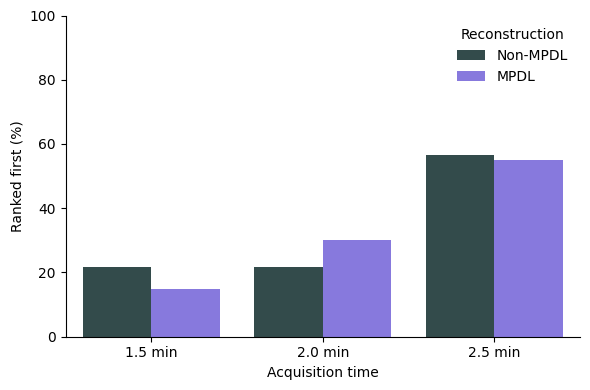

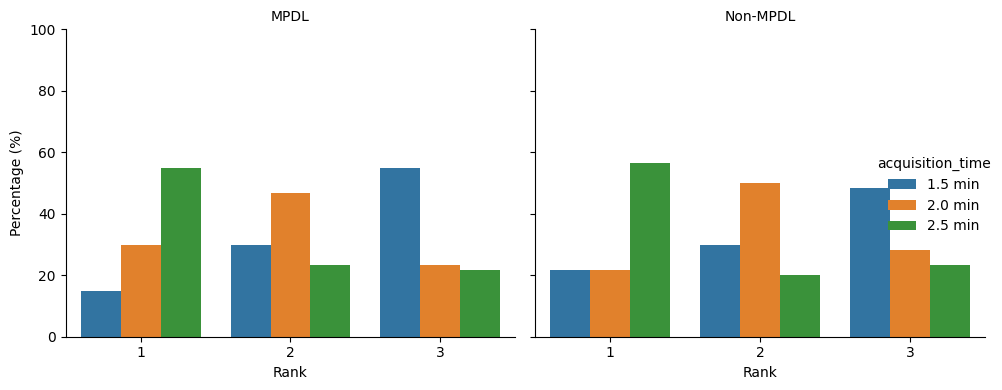

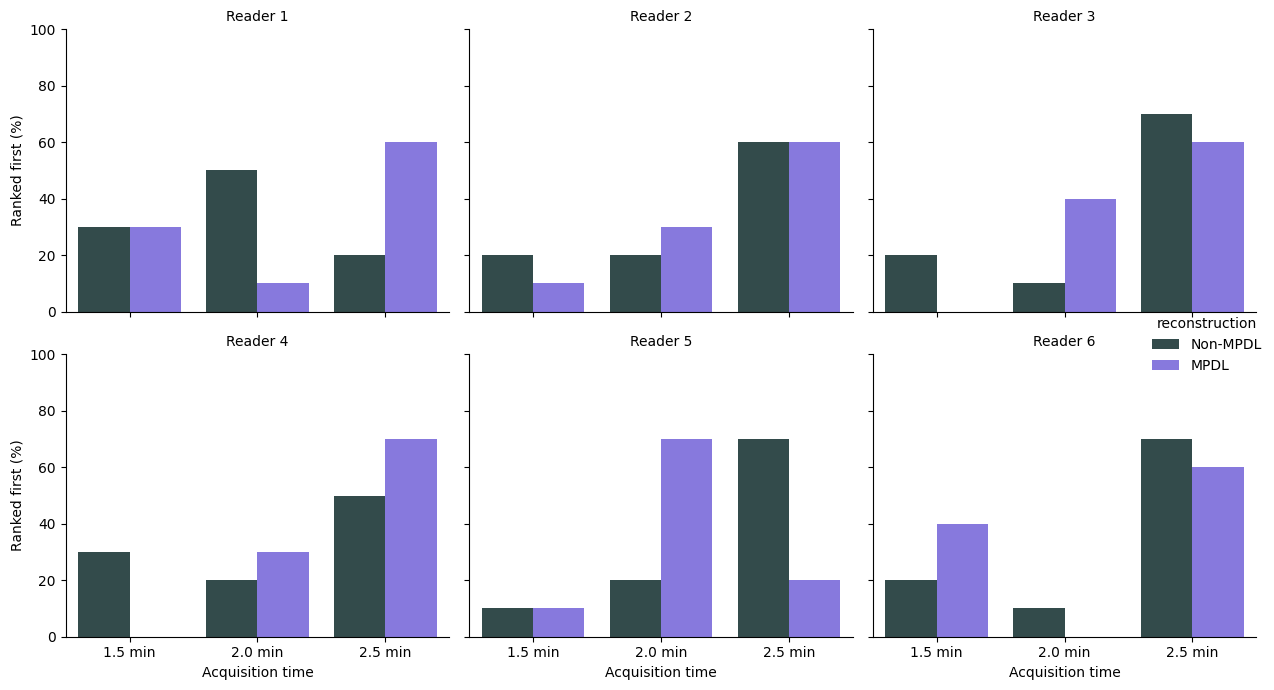

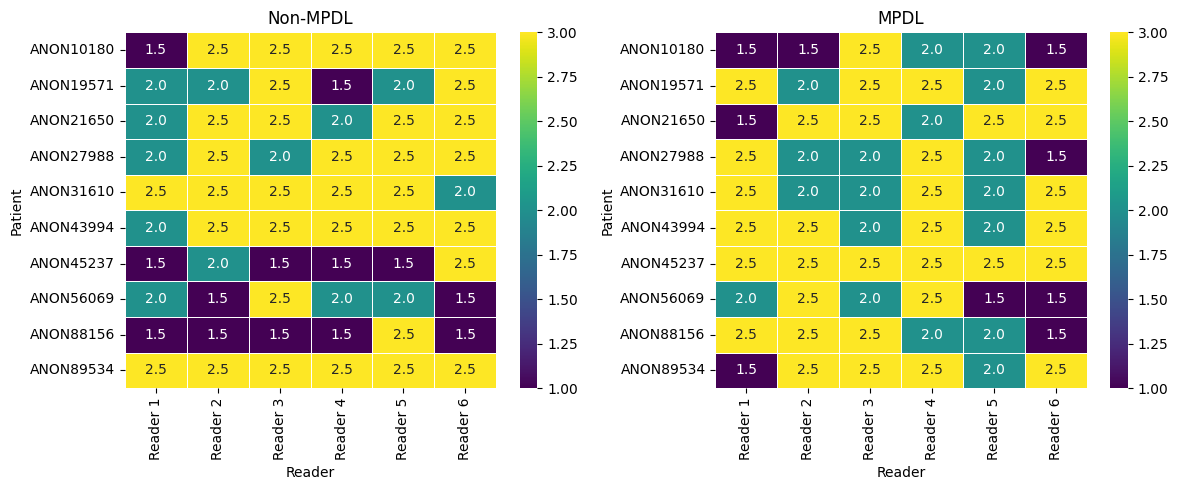

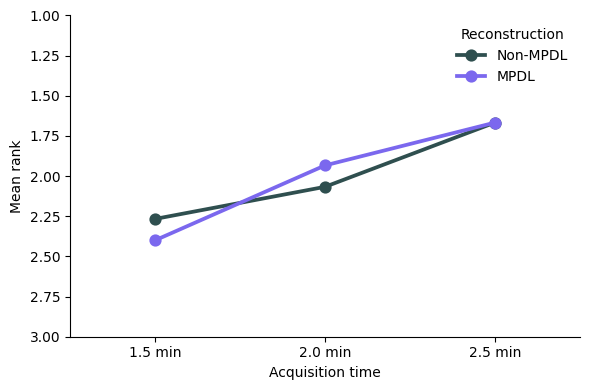


Figures saved to: /Users/aiphuongtong/Desktop/NM/TPB/ranking_figures


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

OUT = Path("ranking_figures")
OUT.mkdir(exist_ok=True)

READER_MAP = {
    "behnia": 1,
    "msadic": 2,
    "noha": 3,
    "mkumar1": 4,
    "oztekma": 5,
    "laithab": 6
}

reader_order = [f"Reader {i}" for i in range(1, 7)]
order        = ["1.5 min", "2.0 min", "2.5 min"]
recon_order  = ["Non-MPDL", "MPDL"]

COLORS = {"MPDL": "#7B68EE","Non-MPDL": "#2F4F4F"}
ids    = pd.read_excel("rank_pet_ids.xlsx")

ids.columns = (ids.columns.astype(str)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True))

mpdl_map = ids.set_index("MPDL-ID")["patient_ID"].to_dict()
qc_map = ids.set_index("QC-ID")["patient_ID"].to_dict()

recon_map = {**{k: (v, "MPDL") for k, v in mpdl_map.items()},
    **{k: (v, "Non-MPDL") for k, v in qc_map.items()}}

compiled["rank_block"] = (compiled["patient_id"].astype(str)
    .str.extract(r"(\d+)")[0]
    .map(lambda x: f"Rank_{int(x):03d}"))

mapped   = compiled["rank_block"].map(recon_map)

compiled["patient_ID"]     = mapped.map(lambda x: x[0] if isinstance(x, tuple) else None)
compiled["reconstruction"] = mapped.map(lambda x: x[1] if isinstance(x, tuple) else None)

long = compiled.melt(id_vars=["reader_name", "patient_ID", "rank_block", "reconstruction"],
    value_vars=["rank1", "rank2", "rank3"],
    var_name="rank_position",
    value_name="acquisition_code")

long["rank_position"]     = long["rank_position"].str.extract(r"(\d+)").astype(int)
long["acquisition_code"]  = long["acquisition_code"].astype(int)
long["acquisition_label"] = long["acquisition_code"].map({1: "a",2: "b",3: "c"})
long["reader_label"]      = long["reader_name"].map(READER_MAP).map(lambda x: f"Reader {x}")

time_maps = {}
for _, r in ids.iterrows():
    time_maps[(r["patient_ID"], "MPDL")] = {
        str(r["1.5 min MPDL"]).strip(): "1.5 min",
        str(r["2.0 min MPDL"]).strip(): "2.0 min",
        str(r["2.5 min MPDL"]).strip(): "2.5 min"}

    time_maps[(r["patient_ID"], "Non-MPDL")] = {
        str(r["1.5 min"]).strip(): "1.5 min",
        str(r["2.0 min"]).strip(): "2.0 min",
        str(r["2.5 min"]).strip(): "2.5 min"}

long["acquisition_time"] = [
    time_maps.get((p, r), {}).get(a)
    for p, r, a in zip(long["patient_ID"],long["reconstruction"],long["acquisition_label"])]

print("\nSUMMARY")
print(f"Total observations: {len(long)}")
print(f"Patients: {long['patient_ID'].nunique()}")
print(f"Readers: {long['reader_name'].nunique()}")

print("\nReconstruction")
print(long["reconstruction"].value_counts().sort_index())

print("\nAcquisition time")
print(long["acquisition_time"].value_counts().sort_index())

print("\nReconstruction × acquisition")
print(long.groupby(["reconstruction", "acquisition_time"]).size().unstack(fill_value=0))

print("\nReconstruction × rank")
print(long.groupby(["reconstruction", "rank_position"]).size().unstack(fill_value=0))

print("\nReconstruction × acquisition × rank")
print(long.groupby(["reconstruction", "acquisition_time", "rank_position"]).size().unstack(fill_value=0))

print("\nReader × reconstruction")
print(long.groupby(["reader_label", "reconstruction"]).size().unstack(fill_value=0))

print("\nReader × reconstruction × acquisition")
print(long.groupby(["reader_label", "reconstruction", "acquisition_time"]).size().unstack(fill_value=0))

print("\nReader × reconstruction × rank")
print(long.groupby(["reader_label", "reconstruction", "rank_position"]).size().unstack(fill_value=0))

print("\nMissing values")
print(long[["patient_ID", "reconstruction", "acquisition_label", "acquisition_time"]].isna().sum())

first             = long[long["rank_position"].eq(1)].copy()
first["time_num"] = first["acquisition_time"].map({"1.5 min": 1,"2.0 min": 2,"2.5 min": 3})
plot = first.groupby(["reconstruction", "acquisition_time"]).size().reset_index(name="n")

plot["percent"]   = (plot["n"] / plot.groupby("reconstruction")["n"].transform("sum") * 100)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=plot,
    x="acquisition_time",
    y="percent",
    hue="reconstruction",
    order=order,
    hue_order=recon_order,
    palette=COLORS,
    errorbar=None
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Acquisition time")
plt.ylabel("Ranked first (%)")
plt.ylim(0, 100)
plt.legend(title="Reconstruction", frameon=False)
plt.tight_layout()
plt.savefig(OUT / "01_first_choice.png", dpi=300, bbox_inches="tight")
plt.show()


plot = long.groupby(["reconstruction", "acquisition_time", "rank_position"]).size().reset_index(name="n")

plot["percent"] = (
    plot["n"] /
    plot.groupby(
        ["reconstruction", "acquisition_time"]
    )["n"].transform("sum") * 100
)

g = sns.catplot(
    data=plot,
    x="rank_position",
    y="percent",
    hue="acquisition_time",
    col="reconstruction",
    kind="bar",
    order=[1, 2, 3],
    hue_order=order,
    errorbar=None,
    height=4,
    aspect=1.1
)

g.set_axis_labels("Rank", "Percentage (%)")
g.set_titles("{col_name}")
g.set(ylim=(0, 100))


plt.tight_layout()
plt.savefig(OUT / "02_rank_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plot = first.groupby(
    ["reader_label", "reconstruction", "acquisition_time"]
).size().reset_index(name="n")

plot["percent"] = (
    plot["n"] /
    plot.groupby(
        ["reader_label", "reconstruction"]
    )["n"].transform("sum") * 100
)

g = sns.catplot(
    data=plot,
    x="acquisition_time",
    y="percent",
    hue="reconstruction",
    col="reader_label",
    col_order=reader_order,
    kind="bar",
    order=order,
    hue_order=recon_order,
    palette=COLORS,
    errorbar=None,
    col_wrap=3,
    height=3.5,
    aspect=1.1
)

g.set_axis_labels("Acquisition time", "Ranked first (%)")
g.set_titles("{col_name}")
g.set(ylim=(0, 100))
plt.tight_layout()
plt.savefig(OUT / "03_reader_first_choice.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, recon in zip(axes, recon_order):

    h = first[first["reconstruction"].eq(recon)].pivot_table(
        index="patient_ID",
        columns="reader_label",
        values="time_num",
        aggfunc="first"
    )

    h = h.reindex(columns=reader_order)

    labels = h.replace({
        1: "1.5",
        2: "2.0",
        3: "2.5"
    })

    sns.heatmap(
        h,
        annot=labels,
        fmt="",
        vmin=1,
        vmax=3,
        cmap="viridis",
        linewidths=0.5,
        cbar=True,
        ax=ax
    )

    ax.set_title(recon)
    ax.set_xlabel("Reader")
    ax.set_ylabel("Patient")

plt.tight_layout()
plt.savefig(OUT / "04_first_choice_heatmaps.png", dpi=300, bbox_inches="tight")
plt.show()

plot = long.groupby(
    ["reconstruction", "acquisition_time"]
)["rank_position"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(6, 4))

sns.pointplot(
    data=plot,
    x="acquisition_time",
    y="mean",
    hue="reconstruction",
    order=order,
    hue_order=recon_order,
    palette=COLORS,
    errorbar=None
)

plt.xlabel("Acquisition time")
plt.ylabel("Mean rank")
plt.ylim(1, 3)
plt.gca().invert_yaxis()
plt.legend(title="Reconstruction", frameon=False)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUT / "05_mean_rank.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFigures saved to: {OUT.resolve()}")

